# 1 — Regresión / Clasificación Ordinal

Las 20 temperaturas tienen **orden natural** (15 → 68 °C). Los clasificadores planos tratan cada clase como independiente y no penalizan más confundir 15 °C con 68 °C que 40 °C con 42 °C.

Este notebook compara:
- **OrdinalRidge** (`mord`): regresión ordinal con regularización L2
- **OrdinalLogistic** (`mord`): logística ordinal (LAD / threshold)
- **Baseline RF** (clasificador estándar): referencia

Métricas adicionales:
- **MAE de clases** (Mean Absolute Error sobre etiquetas ordinales, no solo accuracy)
- **Within-1 accuracy**: % de predicciones que se equivocan como máximo en 1 clase contigua

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import mord

CSV_PATH  = Path("dataset_features_temperatura.csv")
FEAT_JSON = Path("features_seleccionadas.json")

In [2]:
df = pd.read_csv(CSV_PATH)

META_COLS = {
    "sample_uid","sample_id","tx_path","rx_path",
    "tx_path_rel_to_bbdd_parent","rx_path_rel_to_bbdd_parent",
    "split","temperature_folder","N_subcarriers","M_symbols","num_valid","valid_ratio",
}
CONSTANT_COLS = {"phase_jump_m_count","phase_jump_m_ratio","phase_jump_k_count","phase_jump_k_ratio"}

if FEAT_JSON.exists():
    with open(FEAT_JSON) as f: FEAT_COLS = json.load(f)
    print(f"Features desde JSON: {len(FEAT_COLS)}")
else:
    FEAT_COLS = [c for c in df.columns if c not in META_COLS and c != "temperature" and c not in CONSTANT_COLS]
    print(f"Usando todas las features: {len(FEAT_COLS)}")

# Etiqueta ordinal: índice entero 0..N-1 preservando el orden real
temps_sorted = sorted(df["temperature"].unique())
temp2idx = {t: i for i, t in enumerate(temps_sorted)}
df["label_ord"] = df["temperature"].map(temp2idx)

def split_xy(split):
    d = df[df["split"] == split]
    return d[FEAT_COLS].values, d["label_ord"].values

X_tr, y_tr = split_xy("train")
X_v,  y_v  = split_xy("val")
X_te, y_te = split_xy("test")
print(f"Train {X_tr.shape}  Val {X_v.shape}  Test {X_te.shape}")
print(f"Clases ordinales: {temps_sorted}")

Usando todas las features: 58
Train (22566, 58)  Val (4836, 58)  Test (4836, 58)
Clases ordinales: [15.0, 18.0, 24.0, 30.0, 34.0, 36.0, 38.0, 40.0, 42.0, 44.0, 46.0, 48.0, 50.0, 52.0, 54.0, 56.0, 59.0, 61.0, 63.0, 68.0]


In [3]:
# Preprocesado manual (mord no acepta Pipeline directamente)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imp = SimpleImputer(strategy="mean")
scaler = StandardScaler()

X_tr_s = scaler.fit_transform(imp.fit_transform(X_tr))
X_v_s  = scaler.transform(imp.transform(X_v))
X_te_s = scaler.transform(imp.transform(X_te))
print("Preprocesado OK")

Preprocesado OK


In [4]:
def ordinal_metrics(y_true, y_pred, label):
    """Accuracy, MAE de clases, Within-1 accuracy."""
    acc   = accuracy_score(y_true, y_pred)
    mae_c = np.mean(np.abs(y_true.astype(int) - y_pred.astype(int)))
    w1    = np.mean(np.abs(y_true.astype(int) - y_pred.astype(int)) <= 1)
    print(f"{label:30s}  Acc={acc*100:.2f}%  MAE_clases={mae_c:.3f}  Within-1={w1*100:.2f}%")
    return {"acc": acc, "mae_c": mae_c, "w1": w1, "preds": y_pred}

In [5]:
print("Entrenando OrdinalRidge...")
model_or = mord.OrdinalRidge(alpha=1.0)
model_or.fit(X_tr_s, y_tr)
pred_or = model_or.predict(X_te_s).astype(int)
res_or = ordinal_metrics(y_te, pred_or, "OrdinalRidge")

Entrenando OrdinalRidge...
OrdinalRidge                    Acc=16.23%  MAE_clases=2.674  Within-1=42.31%


In [6]:
print("Entrenando LogisticAT (threshold)...")
model_lat = mord.LogisticAT(alpha=1.0)
model_lat.fit(X_tr_s, y_tr)
pred_lat = model_lat.predict(X_te_s).astype(int)
res_lat = ordinal_metrics(y_te, pred_lat, "LogisticAT")

Entrenando LogisticAT (threshold)...
LogisticAT                      Acc=19.23%  MAE_clases=2.480  Within-1=43.44%


In [7]:
print("Entrenando RandomForest (baseline)...")
pipe_rf = Pipeline([
    ("imp",   SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=42))
])
pipe_rf.fit(X_tr, y_tr)
pred_rf = pipe_rf.predict(X_te).astype(int)
res_rf = ordinal_metrics(y_te, pred_rf, "RandomForest (baseline)")

Entrenando RandomForest (baseline)...
RandomForest (baseline)         Acc=96.42%  MAE_clases=0.182  Within-1=97.50%


In [8]:
# ── Tabla resumen ──────────────────────────────────────────────────────────────
rows = [
    {"Modelo": "OrdinalRidge",         "Acc (%)": round(res_or["acc"]*100,2),  "MAE clases": round(res_or["mae_c"],3),  "Within-1 (%)": round(res_or["w1"]*100,2)},
    {"Modelo": "LogisticAT",           "Acc (%)": round(res_lat["acc"]*100,2), "MAE clases": round(res_lat["mae_c"],3), "Within-1 (%)": round(res_lat["w1"]*100,2)},
    {"Modelo": "RandomForest baseline","Acc (%)": round(res_rf["acc"]*100,2),  "MAE clases": round(res_rf["mae_c"],3),  "Within-1 (%)": round(res_rf["w1"]*100,2)},
]
df_res = pd.DataFrame(rows)
print(df_res.to_string(index=False))

               Modelo  Acc (%)  MAE clases  Within-1 (%)
         OrdinalRidge    16.23       2.674         42.31
           LogisticAT    19.23       2.480         43.44
RandomForest baseline    96.42       0.182         97.50


C:\Users\mario\AppData\Local\Temp\ipykernel_18384\3089321619.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([v for v in by_class.values()], labels=[str(temps_sorted[k]) for k in by_class.keys()], vert=True)
C:\Users\mario\AppData\Local\Temp\ipykernel_18384\3089321619.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([v for v in by_class.values()], labels=[str(temps_sorted[k]) for k in by_class.keys()], vert=True)
C:\Users\mario\AppData\Local\Temp\ipykernel_18384\3089321619.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([v for v in by_class.values()], labels=[str(temps_sorte

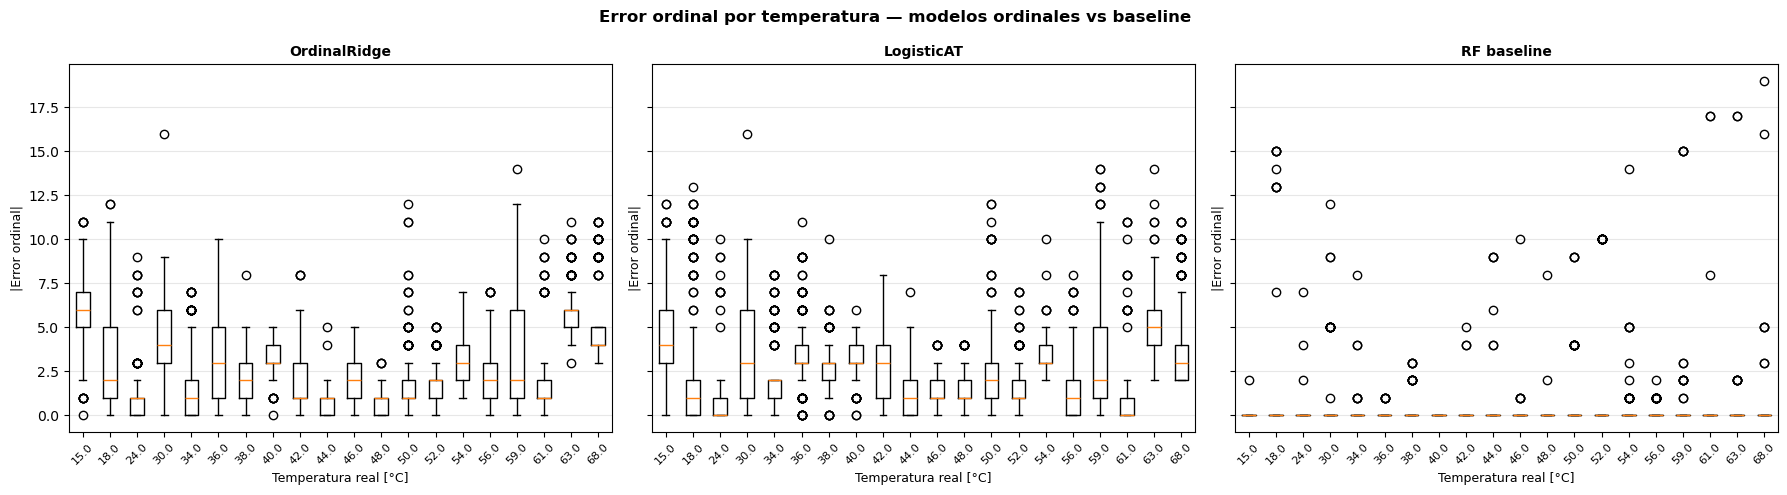

In [9]:
# ── Distribución de error ordinal por clase ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, preds) in zip(axes, [("OrdinalRidge", pred_or),("LogisticAT", pred_lat),("RF baseline", pred_rf)]):
    err = np.abs(y_te.astype(int) - preds.astype(int))
    by_class = {idx: err[y_te == idx] for idx in range(len(temps_sorted)) if (y_te == idx).sum() > 0}
    ax.boxplot([v for v in by_class.values()], labels=[str(temps_sorted[k]) for k in by_class.keys()], vert=True)
    ax.set_xlabel("Temperatura real [°C]", fontsize=9)
    ax.set_ylabel("|Error ordinal|", fontsize=9)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Error ordinal por temperatura — modelos ordinales vs baseline", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("ordinal_error_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

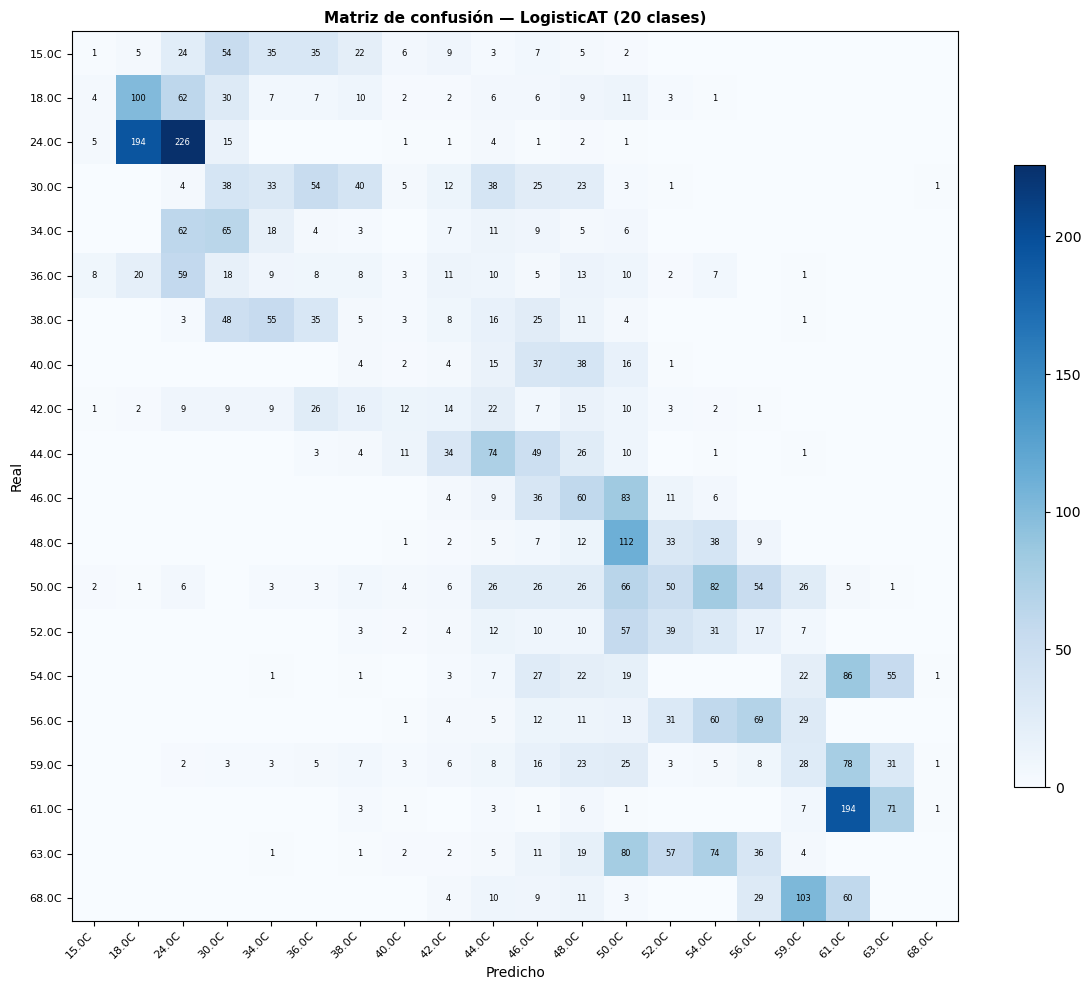

In [10]:
# ── Confusion matrix del mejor modelo ordinal ─────────────────────────────────
best_preds = pred_or if res_or["acc"] >= res_lat["acc"] else pred_lat
best_name  = "OrdinalRidge" if res_or["acc"] >= res_lat["acc"] else "LogisticAT"
labels_str = [str(t) + "C" for t in temps_sorted]
cm = confusion_matrix(y_te, best_preds)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(labels_str))); ax.set_xticklabels(labels_str, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(labels_str))); ax.set_yticklabels(labels_str, fontsize=8)
for i in range(len(labels_str)):
    for j in range(len(labels_str)):
        if cm[i,j] > 0:
            ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=6,
                    color="white" if cm[i,j] > cm.max()*0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_xlabel("Predicho", fontsize=10); ax.set_ylabel("Real", fontsize=10)
ax.set_title(f"Matriz de confusión — {best_name} (20 clases)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("ordinal_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

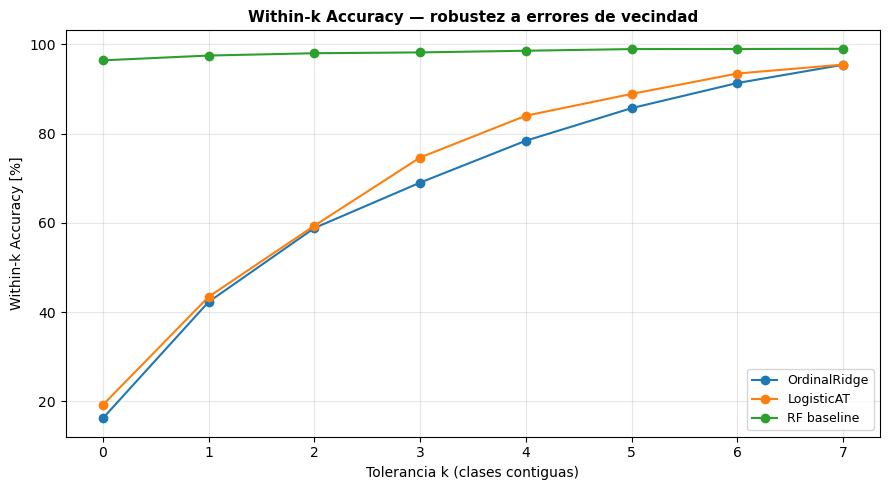

In [11]:
# ── Within-k accuracy: % de preds con error ordinal <= k ──────────────────────
fig, ax = plt.subplots(figsize=(9,5))
ks = range(0, 8)
for name, preds in [("OrdinalRidge", pred_or),("LogisticAT", pred_lat),("RF baseline", pred_rf)]:
    wk = [np.mean(np.abs(y_te.astype(int) - preds.astype(int)) <= k)*100 for k in ks]
    ax.plot(list(ks), wk, marker="o", label=name)
ax.set_xlabel("Tolerancia k (clases contiguas)", fontsize=10)
ax.set_ylabel("Within-k Accuracy [%]", fontsize=10)
ax.set_title("Within-k Accuracy — robustez a errores de vecindad", fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xticks(list(ks))
plt.tight_layout()
plt.savefig("ordinal_within_k.png", dpi=150, bbox_inches="tight")
plt.show()